In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import json
import ast
from scipy.signal import savgol_filter
mpl.rcParams.update({
    "text.usetex": True,              # Enable LaTeX
    # "font.family": "serif",
    # "font.serif": ["Times New Roman"], # Use Times New Roman
    "text.latex.preamble": r"\usepackage{amsmath}"
})

plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams.update()

In [2]:
def rpy_to_rotmat(rpy):
    """
    rpy: (..., 3) roll, pitch, yaw
    returns: (..., 3, 3) rotation matrix (base -> world)
    """
    roll, pitch, yaw = rpy[..., 0], rpy[..., 1], rpy[..., 2]

    cr, sr = np.cos(roll),  np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw),   np.sin(yaw)

    R = np.stack([
        np.stack([cy*cp, cy*sp*sr - sy*cr, cy*sp*cr + sy*sr], axis=-1),
        np.stack([sy*cp, sy*sp*sr + cy*cr, sy*sp*cr - cy*sr], axis=-1),
        np.stack([-sp,   cp*sr,            cp*cr           ], axis=-1)
    ], axis=-2)

    return R


In [3]:
def feet_world_to_base(feet_pos_w, base_pos_w, base_rpy):
    """
    feet_pos_w: (N, n_feet, 3) or (n_feet, 3)
    base_pos_w: (N, 3) or (3,)
    base_rpy:   (N, 3) or (3,)
    returns:    feet_pos_b with same leading shape as feet_pos_w
    """
    feet_pos_w = np.asarray(feet_pos_w)
    base_pos_w = np.asarray(base_pos_w)
    base_rpy   = np.asarray(base_rpy)

    # Ensure batch dimension
    if feet_pos_w.ndim == 2:
        feet_pos_w = feet_pos_w[None, ...]
        base_pos_w = base_pos_w[None, ...]
        base_rpy   = base_rpy[None, ...]

    # Base rotation (base -> world)
    R_w_b = rpy_to_rotmat(base_rpy)

    # Relative foot position in world frame
    p_rel_w = feet_pos_w - base_pos_w[:, None, :]

    # Rotate into base frame: R^T (p_w - p_b)
    feet_pos_b = np.einsum('nij,nfj->nfi', R_w_b.transpose(0, 2, 1), p_rel_w)

    return feet_pos_b


In [4]:
def single_foot_world_to_base(foot_pos_w, base_pos_w, base_rpy):
    """
    foot_pos_w: (N, 3) or (3,)
    base_pos_w: (N, 3) or (3,)
    base_rpy:   (N, 3) or (3,)
    returns:    foot_pos_b with shape (N, 3) or (3,)
    """
    foot_pos_w = np.asarray(foot_pos_w)
    base_pos_w = np.asarray(base_pos_w)
    base_rpy   = np.asarray(base_rpy)

    single = False
    if foot_pos_w.ndim == 1:
        single = True
        foot_pos_w = foot_pos_w[None, :]
        base_pos_w = base_pos_w[None, :]
        base_rpy   = base_rpy[None, :]

    # Base rotation (base → world)
    R_w_b = rpy_to_rotmat(base_rpy)   # (N, 3, 3)

    # Relative foot position in world frame
    p_rel_w = foot_pos_w - base_pos_w  # (N, 3)

    # Rotate into base frame: p_b = R^T (p_w − p_b)
    foot_pos_b = np.einsum('nij,nj->ni', R_w_b.transpose(0, 2, 1), p_rel_w)
    # foot_pos_b = R_w_b.transpose(0, 2, 1) @ p_rel_w

    return foot_pos_b[0] if single else foot_pos_b

In [5]:
side_signs = np.array([-1,1,-1,1])

l1 = 0.08
l2 = 0.213
l3 = 0.216
l4 = 0.0

def calculated_desired_foot_pose(leg_idx, acts):
    side_sign = side_signs[leg_idx]
    
    act_foot_poses = []

    for act in acts:
        q_0 = act[0]
        q_1 = -act[1]
        q_2 = -act[2]

        s1 = np.sin(q_0)
        s2 = np.sin(q_1)
        s3 = np.sin(q_2)

        c1 = np.cos(q_0)
        c2 = np.cos(q_1)
        c3 = np.cos(q_2)

        c23 = c2*c3 - s2*s3
        s23 = s2*c3 + c2*s3

        pos = []

        pos.append(l3*s23 - l2*s2)
        pos.append((l1+l4) * side_sign * c1 + l3*(s1*c23) + l2*c2*s1)
        pos.append((l1+l4) * side_sign * s1 - l3*(c1*c23) - l2*c1 *c2)

        act_foot_poses.append(pos)
    
    return np.array(act_foot_poses)

In [6]:
# Define a function to convert the string representation of an array/list
def string_to_array(array_string):
    try:
        # Use ast.literal_eval to safely evaluate the string as a Python literal
        return ast.literal_eval(array_string)
    except (ValueError, SyntaxError):
        # Handle cases where the string might not be a valid list/array string
        return array_string # Or some default/error value

In [7]:
exp_filepath = "exp_data/full_trained_model_03/forward_turn_02/full_12Lwater_push.csv"
# exp_filepath = "exp_data/full_trained_model_forward_turn/full_12Lwater_push.csv"


payload_df_pd1 = pd.read_csv(exp_filepath, converters={'base_cmd': string_to_array,
                                           'base_pose': string_to_array,
                                           'base_rpy': string_to_array,
                                           'dof_pose': string_to_array,
                                           'base_lin_vel': string_to_array,
                                           'base_ang_vel': string_to_array,
                                           'dof_vel': string_to_array,
                                           'proj_grav': string_to_array,
                                           'feet_pos': string_to_array,
                                           'tau_act': string_to_array,
                                           'grf': string_to_array,
                                           'q_des': string_to_array,
                                           'tau_ff': string_to_array,
                                           'tau_pd': string_to_array,
                                           'failure': string_to_array,
                                           'pred_grf': string_to_array})

print(len(payload_df_pd1))

40000


In [8]:
exp_filepath = "exp_data/full_trained_model_03/forward_turn_02/full_12Lwater_push_pd0.csv"
# exp_filepath = "exp_data/full_trained_model_forward_turn/full_12Lwater_push.csv"


payload_df_pd0 = pd.read_csv(exp_filepath, converters={'base_cmd': string_to_array,
                                           'base_pose': string_to_array,
                                           'base_rpy': string_to_array,
                                           'dof_pose': string_to_array,
                                           'base_lin_vel': string_to_array,
                                           'base_ang_vel': string_to_array,
                                           'dof_vel': string_to_array,
                                           'proj_grav': string_to_array,
                                           'feet_pos': string_to_array,
                                           'tau_act': string_to_array,
                                           'grf': string_to_array,
                                           'q_des': string_to_array,
                                           'tau_ff': string_to_array,
                                           'tau_pd': string_to_array,
                                           'failure': string_to_array,
                                           'pred_grf': string_to_array})

print(len(payload_df_pd1))

40000


In [9]:
exp_filepath = "exp_data/full_trained_model_03/forward_turn_02/full_12Lwater_push_pd2.csv"
# exp_filepath = "exp_data/full_trained_model_forward_turn/full_12Lwater_push.csv"


payload_df_pd2 = pd.read_csv(exp_filepath, converters={'base_cmd': string_to_array,
                                           'base_pose': string_to_array,
                                           'base_rpy': string_to_array,
                                           'dof_pose': string_to_array,
                                           'base_lin_vel': string_to_array,
                                           'base_ang_vel': string_to_array,
                                           'dof_vel': string_to_array,
                                           'proj_grav': string_to_array,
                                           'feet_pos': string_to_array,
                                           'tau_act': string_to_array,
                                           'grf': string_to_array,
                                           'q_des': string_to_array,
                                           'tau_ff': string_to_array,
                                           'tau_pd': string_to_array,
                                           'failure': string_to_array,
                                           'pred_grf': string_to_array})

print(len(payload_df_pd1))

40000


In [10]:
exp_filepath = "exp_data/full_trained_model_03/forward_turn_02/full_12Lwater_push_pd3.csv"
# exp_filepath = "exp_data/full_trained_model_forward_turn/full_12Lwater_push.csv"


payload_df_pd3 = pd.read_csv(exp_filepath, converters={'base_cmd': string_to_array,
                                           'base_pose': string_to_array,
                                           'base_rpy': string_to_array,
                                           'dof_pose': string_to_array,
                                           'base_lin_vel': string_to_array,
                                           'base_ang_vel': string_to_array,
                                           'dof_vel': string_to_array,
                                           'proj_grav': string_to_array,
                                           'feet_pos': string_to_array,
                                           'tau_act': string_to_array,
                                           'grf': string_to_array,
                                           'q_des': string_to_array,
                                           'tau_ff': string_to_array,
                                           'tau_pd': string_to_array,
                                           'failure': string_to_array,
                                           'pred_grf': string_to_array})

print(len(payload_df_pd1))

40000


In [11]:
exp_filepath = "exp_data/full_trained_model_03/forward_turn_02/full_0Lnone_push.csv"
# exp_filepath = "exp_data/full_trained_model_forward_turn/full_0Lnone_push.csv"


noload_df = pd.read_csv(exp_filepath, converters={'base_cmd': string_to_array,
                                           'base_pose': string_to_array,
                                           'base_rpy': string_to_array,
                                           'dof_pose': string_to_array,
                                           'base_lin_vel': string_to_array,
                                           'base_ang_vel': string_to_array,
                                           'dof_vel': string_to_array,
                                           'proj_grav': string_to_array,
                                           'feet_pos': string_to_array,
                                           'tau_act': string_to_array,
                                           'grf': string_to_array,
                                           'q_des': string_to_array,
                                           'tau_ff': string_to_array,
                                           'tau_pd': string_to_array,
                                           'failure': string_to_array,
                                           'pred_grf': string_to_array})

print(len(noload_df))

40000


### Build Left vs. Right FF Torques, PD=1, 12L vs. 0L

In [12]:
left_ff_tau = np.linalg.norm(np.array(payload_df_pd1["tau_ff"].to_list())[:, [3,4,5,9,10,11]], axis=1)
right_ff_tau = np.linalg.norm(np.array(payload_df_pd1["tau_ff"].to_list())[:, [0,1,2,6,7,8]], axis=1)

nl_left_ff_tau = np.linalg.norm(np.array(noload_df["tau_ff"].to_list())[:, [3,4,5,9,10,11]], axis=1)
nl_right_ff_tau = np.linalg.norm(np.array(noload_df["tau_ff"].to_list())[:, [0,1,2,6,7,8]], axis=1)

In [13]:
# DEF row - load, side, then value
# load as 10L Left, 0L left, 10L right, 0L right
load_labels = ["12L" for _ in range(len(left_ff_tau))]
load_labels.extend(["0L" for _ in range(len(nl_left_ff_tau))])
load_labels.extend(["12L" for _ in range(len(right_ff_tau))])
load_labels.extend(["0L" for _ in range(len(nl_right_ff_tau))])

side_labels = ["Left" for _ in range(len(left_ff_tau))]
side_labels.extend(["Left" for _ in range(len(nl_left_ff_tau))])
side_labels.extend(["Right" for _ in range(len(right_ff_tau))])
side_labels.extend(["Right" for _ in range(len(nl_right_ff_tau))])


value = []
value.extend(left_ff_tau.tolist())
value.extend(nl_left_ff_tau.tolist())
value.extend(right_ff_tau.tolist())
value.extend(nl_right_ff_tau.tolist())


ff_tau_comp_df = pd.DataFrame()

ff_tau_comp_df["Load"] = load_labels
ff_tau_comp_df["Side"] = side_labels
ff_tau_comp_df["FF_Tau_Norm"] = value

Text(0, 0.5, 'Feedforward Torque Norm (Nm)')

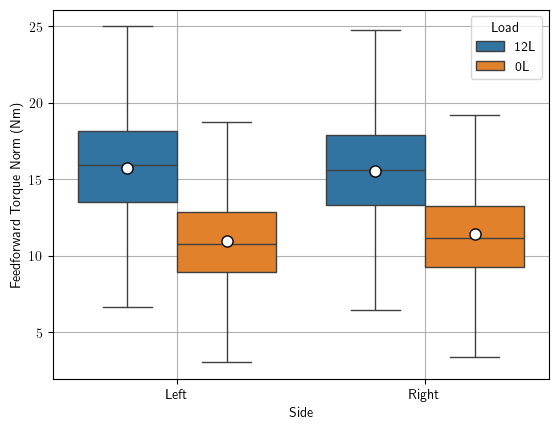

In [14]:
ax = sns.boxplot(data=ff_tau_comp_df, x="Side", y="FF_Tau_Norm", 
            hue="Load", showfliers=False,
                             showmeans=True,
                     meanprops={
                         "marker": "o",   # Use a circle marker for the mean
                         "markerfacecolor": "white",
                         "markeredgecolor": "black",
                         "markersize": "8"
                         })
ax.grid()
ax.set_ylabel("Feedforward Torque Norm (Nm)")

/tmp/ipykernel_1439065/2057051120.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Left", "Right"], fontsize=16)
/tmp/ipykernel_1439065/2057051120.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(np.round(ax.get_yticks(),0), fontsize=12)


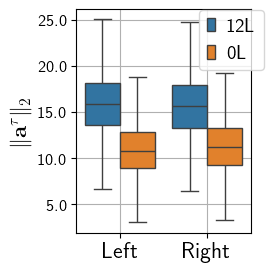

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(2.25, 2.9))

# ax.set_ylabel(r"$\Vert\mathbf{a}^{\tau}\Vert_{2}$ and $\Vert\boldsymbol{\tau}^{PD}\Vert_{2}$", fontsize=16)


sns.boxplot(data=ff_tau_comp_df, x="Side", y="FF_Tau_Norm", hue="Load", showfliers=False, ax=ax)
ax.grid()
ax.set_ylabel(r"$\Vert\mathbf{a}^{\tau}\Vert_{2}$", fontsize=16)
ax.set_xlabel("", fontsize=1)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.65, 1.04),  # just outside upper-right
    ncol=1,          # or more, depending on entries
    frameon=True,
    fontsize=14,
    handlelength=0.4,    # shorter legend lines
    handletextpad=0.6)    # spacing between line and text)
ax.set_xticklabels(["Left", "Right"], fontsize=16)
ax.set_yticklabels(np.round(ax.get_yticks(),0), fontsize=12)

# ax.set_ylabel("PD Torque Norm (Nm)")
# fig.tight_layout()

fig.savefig(
    "ff_tau_side_vs_payload.png",
    dpi=1000,
    bbox_inches="tight",
    pad_inches=0.02
)

/tmp/ipykernel_1439065/3350140770.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Left", "Right"], fontsize=14)


[Text(0, 0, 'Left'), Text(1, 0, 'Right')]

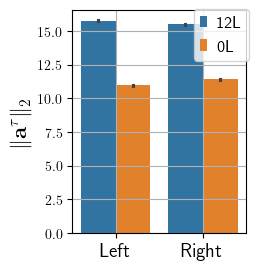

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(2.25, 2.9))

# ax.set_ylabel(r"$\Vert\mathbf{a}^{\tau}\Vert_{2}$ and $\Vert\boldsymbol{\tau}^{PD}\Vert_{2}$", fontsize=16)


sns.barplot(data=ff_tau_comp_df, x="Side", y="FF_Tau_Norm", hue="Load", ax=ax)
ax.grid()
ax.set_ylabel(r"$\Vert\mathbf{a}^{\tau}\Vert_{2}$", fontsize=16)
ax.set_xlabel("", fontsize=1)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.65, 1.04),  # just outside upper-right
    ncol=1,          # or more, depending on entries
    frameon=True,
    fontsize=12,
    handlelength=0.4,    # shorter legend lines
    handletextpad=0.6)    # spacing between line and text)
ax.set_xticklabels(["Left", "Right"], fontsize=14)

# ax.set_ylabel("PD Torque Norm (Nm)")
# fig.tight_layout()

# fig.savefig(
#     "ff_tau_side_vs_payload.png",
#     dpi=300,
#     bbox_inches="tight",
#     pad_inches=0.02
# )

### Left vs. Right PD torques, PD=1, 12L vs 0L

In [17]:
left_pd_tau = np.linalg.norm(np.array(payload_df_pd1["tau_pd"].to_list())[:, [3,4,5,9,10,11]], axis=1)
right_pd_tau = np.linalg.norm(np.array(payload_df_pd1["tau_pd"].to_list())[:, [0,1,2,6,7,8]], axis=1)

nl_left_pd_tau = np.linalg.norm(np.array(noload_df["tau_pd"].to_list())[:, [3,4,5,9,10,11]], axis=1)
nl_right_pd_tau = np.linalg.norm(np.array(noload_df["tau_pd"].to_list())[:, [0,1,2,6,7,8]], axis=1)

load_labels = ["12L" for _ in range(len(left_pd_tau))]
load_labels.extend(["0L" for _ in range(len(nl_left_pd_tau))])
load_labels.extend(["12L" for _ in range(len(right_pd_tau))])
load_labels.extend(["0L" for _ in range(len(nl_right_pd_tau))])

side_labels = ["Left" for _ in range(len(left_pd_tau))]
side_labels.extend(["Left" for _ in range(len(nl_left_pd_tau))])
side_labels.extend(["Right" for _ in range(len(right_pd_tau))])
side_labels.extend(["Right" for _ in range(len(nl_right_pd_tau))])


value = []
value.extend(left_pd_tau.tolist())
value.extend(nl_left_pd_tau.tolist())
value.extend(right_pd_tau.tolist())
value.extend(nl_right_pd_tau.tolist())

pd_tau_comp_df = pd.DataFrame()

pd_tau_comp_df["Load"] = load_labels
pd_tau_comp_df["Side"] = side_labels
pd_tau_comp_df["PD_Tau_Norm"] = value


Text(0, 0.5, 'PD Torque Norm (Nm)')

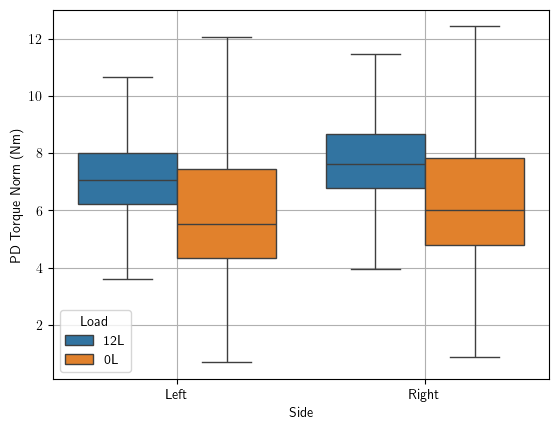

In [18]:
ax = sns.boxplot(data=pd_tau_comp_df, x="Side", y="PD_Tau_Norm", hue="Load", showfliers=False)
ax.grid()
ax.set_ylabel("PD Torque Norm (Nm)")

/tmp/ipykernel_1439065/998546635.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Left", "Right"], fontsize=16)
/tmp/ipykernel_1439065/998546635.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(np.round(ax.get_yticks(),0), fontsize=12)


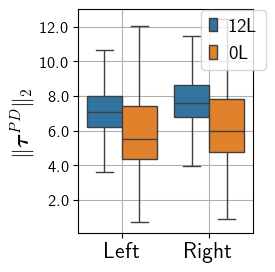

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(2.25, 2.9))

# ax.set_ylabel(r"$\Vert\mathbf{a}^{\tau}\Vert_{2}$ and $\Vert\boldsymbol{\tau}^{PD}\Vert_{2}$", fontsize=16)


sns.boxplot(data=pd_tau_comp_df, x="Side", y="PD_Tau_Norm", hue="Load", showfliers=False, ax=ax)
ax.grid()
ax.set_ylabel(r"$\Vert\boldsymbol{\tau}^{PD}\Vert_{2}$", fontsize=16)
ax.set_xlabel("", fontsize=1)
ax.legend(
    loc="upper left",
    bbox_to_anchor=(0.65, 1.04),  # just outside upper-right
    ncol=1,          # or more, depending on entries
    frameon=True,
    fontsize=14,
    handlelength=0.4,    # shorter legend lines
    handletextpad=0.6)    # spacing between line and text)
ax.set_xticklabels(["Left", "Right"], fontsize=16)
ax.set_yticklabels(np.round(ax.get_yticks(),0), fontsize=12)

# ax.set_ylabel("PD Torque Norm (Nm)")
# fig.tight_layout()

fig.savefig(
    "pd_tau_side_vs_payload.png",
    dpi=1000,
    bbox_inches="tight",
    pad_inches=0.02
)

### Norm and angle side-by-side plots

In [20]:
# Pull out values for payload data
front_right_contact = payload_df_pd1[(np.array(payload_df_pd1["grf"].to_list())[:,2] > 1.0)]
front_left_contact = payload_df_pd1[(np.array(payload_df_pd1["grf"].to_list())[:,5] > 1.0)]
rear_right_contact = payload_df_pd1[(np.array(payload_df_pd1["grf"].to_list())[:,8] > 1.0)]
rear_left_contact = payload_df_pd1[(np.array(payload_df_pd1["grf"].to_list())[:,11] > 1.0)]

# Clauclate pose in base-frame
fr_foot_pose_base = single_foot_world_to_base(np.array(front_right_contact["feet_pos"].to_list())[:,0,:], 
                                              np.array(front_right_contact["base_pose"].to_list()), 
                                              np.array(front_right_contact["base_rpy"].to_list()))

fl_foot_pose_base = single_foot_world_to_base(np.array(front_left_contact["feet_pos"].to_list())[:,1,:], 
                                              np.array(front_left_contact["base_pose"].to_list()), 
                                              np.array(front_left_contact["base_rpy"].to_list()))

rr_foot_pose_base = single_foot_world_to_base(np.array(rear_right_contact["feet_pos"].to_list())[:,2,:], 
                                              np.array(rear_right_contact["base_pose"].to_list()), 
                                              np.array(rear_right_contact["base_rpy"].to_list()))

rl_foot_pose_base = single_foot_world_to_base(np.array(rear_left_contact["feet_pos"].to_list())[:,3,:], 
                                              np.array(rear_left_contact["base_pose"].to_list()), 
                                              np.array(rear_left_contact["base_rpy"].to_list()))

fr_gootpos_norm = np.linalg.norm(fr_foot_pose_base[:,:2], axis=1)
print("Front-Right Contact - ", np.round(np.mean(fr_gootpos_norm), 4))

fl_gootpos_norm = np.linalg.norm(fl_foot_pose_base[:,:2], axis=1)
print("Front-Left Contact - ", np.round(np.mean(fl_gootpos_norm), 4))

rr_gootpos_norm = np.linalg.norm(rr_foot_pose_base[:,:2], axis=1)
print("Rear-Right Contact - ", np.round(np.mean(rr_gootpos_norm), 4))

rl_gootpos_norm = np.linalg.norm(rl_foot_pose_base[:,:2], axis=1)
print("Rear-Left Contact - ", np.round(np.mean(rl_gootpos_norm), 4))


total_norms = np.concatenate([fr_gootpos_norm, fl_gootpos_norm, rr_gootpos_norm, rl_gootpos_norm], axis=0)
print("Total Contact - ", np.round(np.mean(total_norms), 4))


all_foot_poses = np.concatenate([fr_foot_pose_base[:,:2], fl_foot_pose_base[:,:2], rr_foot_pose_base[:,:2], rl_foot_pose_base[:,:2]], axis=0)
angles = np.arctan(np.abs(all_foot_poses[:,0]) / np.abs(all_foot_poses[:,1]))
np.mean(angles * (180.0/np.pi))

Front-Right Contact -  0.2225
Front-Left Contact -  0.2218
Rear-Right Contact -  0.2853
Rear-Left Contact -  0.2999
Total Contact -  0.2572


np.float64(59.24199481546623)

In [21]:
nl_front_right_contact = noload_df[(np.array(noload_df["grf"].to_list())[:,2] > 1.0)]
nl_front_left_contact  = noload_df[(np.array(noload_df["grf"].to_list())[:,5] > 1.0)]
nl_rear_right_contact  = noload_df[(np.array(noload_df["grf"].to_list())[:,8] > 1.0)]
nl_rear_left_contact   = noload_df[(np.array(noload_df["grf"].to_list())[:,11] > 1.0)]


nl_fr_foot_pose_base = single_foot_world_to_base(np.array(nl_front_right_contact["feet_pos"].to_list())[:,0,:], 
                                                 np.array(nl_front_right_contact["base_pose"].to_list()), 
                                                 np.array(nl_front_right_contact["base_rpy"].to_list()))

nl_fl_foot_pose_base = single_foot_world_to_base(np.array(nl_front_left_contact["feet_pos"].to_list())[:,1,:], 
                                                 np.array(nl_front_left_contact["base_pose"].to_list()), 
                                                 np.array(nl_front_left_contact["base_rpy"].to_list()))

nl_rr_foot_pose_base = single_foot_world_to_base(np.array(nl_rear_right_contact["feet_pos"].to_list())[:,2,:], 
                                                 np.array(nl_rear_right_contact["base_pose"].to_list()), 
                                                 np.array(nl_rear_right_contact["base_rpy"].to_list()))

nl_rl_foot_pose_base = single_foot_world_to_base(np.array(nl_rear_left_contact["feet_pos"].to_list())[:,3,:], 
                                                 np.array(nl_rear_left_contact["base_pose"].to_list()), 
                                                 np.array(nl_rear_left_contact["base_rpy"].to_list()))

nl_fr_gootpos_norm = np.linalg.norm(nl_fr_foot_pose_base[:,:2], axis=1)
print("NL Front-Right Contact - ", np.round(np.mean(nl_fr_gootpos_norm), 4))

nl_fl_gootpos_norm = np.linalg.norm(nl_fl_foot_pose_base[:,:2], axis=1)
print("NL Front-Right Contact - ", np.round(np.mean(nl_fl_gootpos_norm), 4))

nl_rr_gootpos_norm = np.linalg.norm(nl_rr_foot_pose_base[:,:2], axis=1)
print("NL Front-Right Contact - ", np.round(np.mean(nl_rr_gootpos_norm), 4))

nl_rl_gootpos_norm = np.linalg.norm(nl_rl_foot_pose_base[:,:2], axis=1)
print("NL Front-Right Contact - ", np.round(np.mean(nl_rl_gootpos_norm), 4))

nl_total_norms = np.concatenate([nl_fr_gootpos_norm, nl_fl_gootpos_norm, nl_rr_gootpos_norm, nl_rl_gootpos_norm], axis=0)
print("NL Total Contact - ", np.round(np.mean(nl_total_norms), 4))

nl_all_foot_poses = np.concatenate([nl_fr_foot_pose_base[:,:2], nl_fl_foot_pose_base[:,:2], nl_rr_foot_pose_base[:,:2], nl_rl_foot_pose_base[:,:2]], axis=0)

nl_angles = np.arctan(np.abs(nl_all_foot_poses[:,0]) / np.abs(nl_all_foot_poses[:,1]))

np.mean(nl_angles * (180.0/np.pi))

NL Front-Right Contact -  0.2033
NL Front-Right Contact -  0.2004
NL Front-Right Contact -  0.2915
NL Front-Right Contact -  0.3035
NL Total Contact -  0.2474


np.float64(60.745832205998525)

In [22]:
# Norm - row = Load, value

load_labels = ["12L" for _ in range(0, len(total_norms))]
load_labels.extend(["0L" for _ in range(0, len(nl_total_norms))])

values = total_norms.tolist()
values.extend(nl_total_norms.tolist())

temp_norm_df = pd.DataFrame()
temp_norm_df["Payload"] = load_labels
temp_norm_df["Step_Mag"] = values

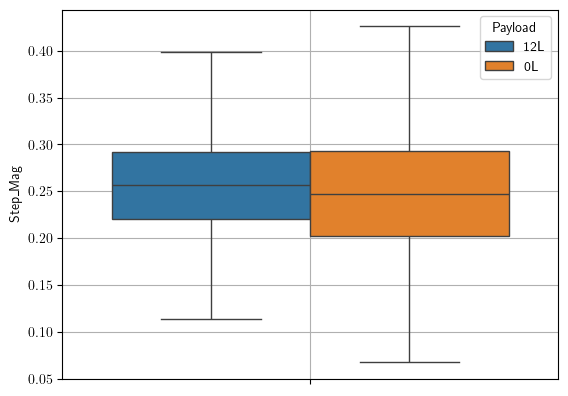

In [23]:
ax = sns.boxplot(data=temp_norm_df, y="Step_Mag", hue="Payload", showfliers=False)
ax.grid()
# ax.set_ylabel("PD Torque Norm (Nm)")

In [24]:
# Norm - row = Load, value

load_labels = ["12L" for _ in range(0, len(angles))]
load_labels.extend(["0L" for _ in range(0, len(nl_angles))])

values = angles.tolist()
values.extend(nl_angles.tolist())

temp_ang_df = pd.DataFrame()
temp_ang_df["Payload"] = load_labels
temp_ang_df["Step_Ang"] = values

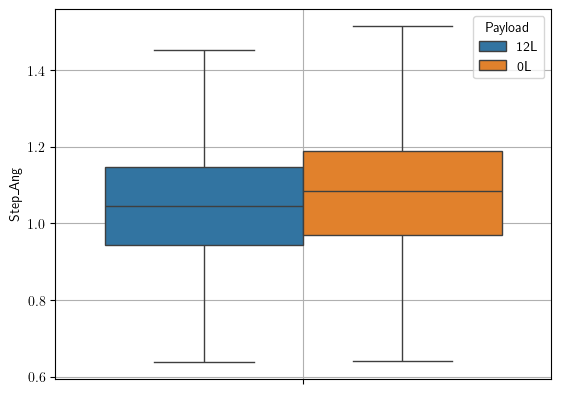

In [25]:
ax = sns.boxplot(data=temp_ang_df, y="Step_Ang", hue="Payload", showfliers=False)
ax.grid()
# ax.set_ylabel("PD Torque Norm (Nm)")

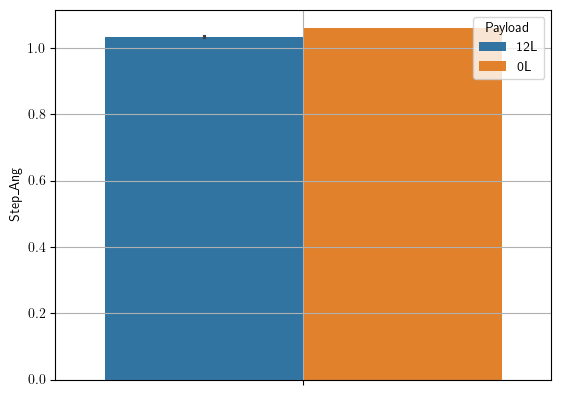

In [26]:
ax = sns.barplot(data=temp_ang_df, y="Step_Ang", hue="Payload")
ax.grid()

In [27]:
### Linear and Angular performance vs Pd Value
#   PD = 0
lin_vel_pd0 = np.array(payload_df_pd0["base_lin_vel"].to_list())
ang_vel_pd0 = np.array(payload_df_pd0["base_ang_vel"].to_list())
cmds_pd0    = np.array(payload_df_pd0["base_cmd"].to_list())

lin_cmd_errors_pd0 = np.sqrt(np.mean(np.square(cmds_pd0[:,0:2] - lin_vel_pd0[:,0:2]), axis=1))
ang_cmd_errors_pd0 = np.sqrt(np.square(cmds_pd0[:,2] - ang_vel_pd0[:,2]))

#   PD = 1
lin_vel_pd1 = np.array(payload_df_pd1["base_lin_vel"].to_list())
ang_vel_pd1 = np.array(payload_df_pd1["base_ang_vel"].to_list())
cmds_pd1    = np.array(payload_df_pd1["base_cmd"].to_list())

lin_cmd_errors_pd1 = np.sqrt(np.mean(np.square(cmds_pd1[:,0:2] - lin_vel_pd1[:,0:2]), axis=1))
ang_cmd_errors_pd1 = np.sqrt(np.square(cmds_pd1[:,2] - ang_vel_pd1[:,2]))

#   PD = 2
lin_vel_pd2 = np.array(payload_df_pd2["base_lin_vel"].to_list())
ang_vel_pd2 = np.array(payload_df_pd2["base_ang_vel"].to_list())
cmds_pd2    = np.array(payload_df_pd2["base_cmd"].to_list())

lin_cmd_errors_pd2 = np.sqrt(np.mean(np.square(cmds_pd2[:,0:2] - lin_vel_pd2[:,0:2]), axis=1))
ang_cmd_errors_pd2 = np.sqrt(np.square(cmds_pd2[:,2] - ang_vel_pd2[:,2]))

#   PD = 3
lin_vel_pd3 = np.array(payload_df_pd3["base_lin_vel"].to_list())
ang_vel_pd3 = np.array(payload_df_pd3["base_ang_vel"].to_list())
cmds_pd3    = np.array(payload_df_pd3["base_cmd"].to_list())

lin_cmd_errors_pd3 = np.sqrt(np.mean(np.square(cmds_pd3[:,0:2] - lin_vel_pd3[:,0:2]), axis=1))
ang_cmd_errors_pd3 = np.sqrt(np.square(cmds_pd3[:,2] - ang_vel_pd3[:,2]))

In [28]:
ang_cmd_errors_pd0

array([0.63757753, 0.24747307, 0.09423365, ..., 0.10213333, 0.35099535,
       0.18086761], shape=(40000,))

In [29]:
# DEF row - type (lin/ang), PD [0,1,2,3], Value
type_labels = [r"$\mathbf{v}_{x,y}^{e}$" for _ in range(len(lin_cmd_errors_pd0))]
type_labels.extend([r"$\mathbf{v}_{x,y}^{e}$" for _ in range(len(lin_cmd_errors_pd1))])
type_labels.extend([r"$\mathbf{v}_{x,y}^{e}$" for _ in range(len(lin_cmd_errors_pd2))])
type_labels.extend([r"$\mathbf{v}_{x,y}^{e}$" for _ in range(len(lin_cmd_errors_pd3))])
type_labels.extend([r"$\omega_{yaw}^{e}$" for _ in range(len(ang_cmd_errors_pd0))])
type_labels.extend([r"$\omega_{yaw}^{e}$" for _ in range(len(ang_cmd_errors_pd1))])
type_labels.extend([r"$\omega_{yaw}^{e}$" for _ in range(len(ang_cmd_errors_pd2))])
type_labels.extend([r"$\omega_{yaw}^{e}$" for _ in range(len(ang_cmd_errors_pd3))])


pd_labels = ["0.0" for _ in range(len(lin_cmd_errors_pd0))]
pd_labels.extend(["1.0" for _ in range(len(lin_cmd_errors_pd1))])
pd_labels.extend(["2.0" for _ in range(len(lin_cmd_errors_pd2))])
pd_labels.extend(["3.0" for _ in range(len(lin_cmd_errors_pd3))])
pd_labels.extend(["0.0" for _ in range(len(ang_cmd_errors_pd0))])
pd_labels.extend(["1.0" for _ in range(len(ang_cmd_errors_pd1))])
pd_labels.extend(["2.0" for _ in range(len(ang_cmd_errors_pd2))])
pd_labels.extend(["3.0" for _ in range(len(ang_cmd_errors_pd3))])


value = []
value.extend(lin_cmd_errors_pd0.tolist())
value.extend(lin_cmd_errors_pd1.tolist())
value.extend(lin_cmd_errors_pd2.tolist())
value.extend(lin_cmd_errors_pd3.tolist())
value.extend(ang_cmd_errors_pd0.tolist())
value.extend(ang_cmd_errors_pd1.tolist())
value.extend(ang_cmd_errors_pd2.tolist())
value.extend(ang_cmd_errors_pd3.tolist())


per_compare_df = pd.DataFrame()

per_compare_df["Type"] = type_labels
per_compare_df["PD"] = pd_labels
per_compare_df["Performance"] = value

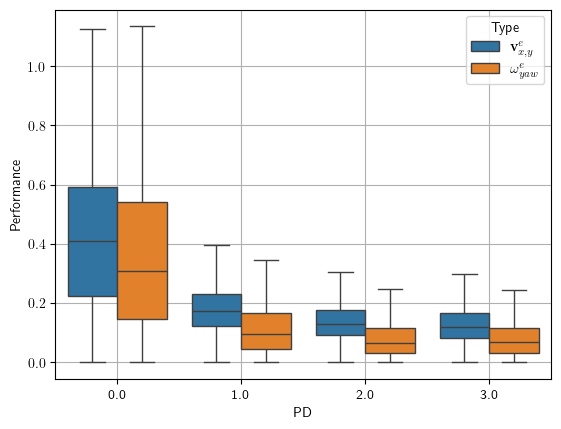

In [30]:
ax = sns.boxplot(data=per_compare_df, x="PD", y="Performance", hue="Type", showfliers=False)
ax.grid()
# ax.set_ylabel("PD Torque Norm (Nm)")

/tmp/ipykernel_1439065/3683819115.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(np.round(ax.get_yticks(),0), fontsize=12)
/tmp/ipykernel_1439065/3683819115.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(ax.get_xticks(),1), fontsize=12)


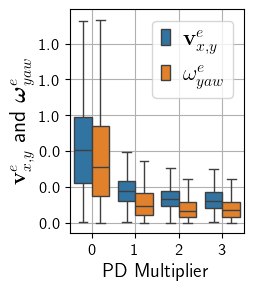

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(2.25, 2.9))

sns.boxplot(data=per_compare_df, x="PD", y="Performance", hue="Type", showfliers=False, ax=ax)
ax.grid()
ax.set_ylabel(r"$\mathbf{v}_{x,y}^{e}$ and $\boldsymbol{\omega}_{yaw}^{e}$", fontsize=16)
ax.set_xlabel("PD Multiplier", fontsize=14, fontweight="bold")
ax.legend(
    # loc="upper left",
    # bbox_to_anchor=(0.47, 1.04),  # just outside upper-right
    ncol=1,          # or more, depending on entries
    frameon=True,
    fontsize=16,
    handlelength=0.4,    # shorter legend lines
    handletextpad=0.6)    # spacing between line and text)
# ax.set_ylabel("PD Torque Norm (Nm)")
# fig.tight_layout()

ax.set_yticklabels(np.round(ax.get_yticks(),0), fontsize=12)
ax.set_xticklabels(np.round(ax.get_xticks(),1), fontsize=12)


fig.savefig(
    "pd_mult_vs_tracking.png",
    dpi=1000,
    bbox_inches="tight",
    pad_inches=0.02
)

In [32]:
ff_tau_pd0 = np.linalg.norm(np.array(payload_df_pd0["tau_ff"].to_list()), axis=1)
pd_tau_pd0 = np.linalg.norm(np.array(payload_df_pd0["tau_pd"].to_list())*0.0, axis=1)
q_mag_pd0 = np.linalg.norm(np.array(payload_df_pd0["q_des"].to_list()), axis=1)

print(np.mean(np.abs(q_mag_pd0)))

ff_tau_pd1 = np.linalg.norm(np.array(payload_df_pd1["tau_ff"].to_list()), axis=1)
pd_tau_pd1 = np.linalg.norm(np.array(payload_df_pd1["tau_pd"].to_list())*1.0, axis=1)
q_mag_pd1 = np.linalg.norm(np.array(payload_df_pd1["q_des"].to_list()), axis=1)

print(np.mean(np.abs(q_mag_pd1)))

ff_tau_pd2 = np.linalg.norm(np.array(payload_df_pd2["tau_ff"].to_list()), axis=1)
pd_tau_pd2 = np.linalg.norm(np.array(payload_df_pd2["tau_pd"].to_list())*2.0, axis=1)
q_mag_pd2 = np.linalg.norm(np.array(payload_df_pd2["q_des"].to_list()), axis=1)

print(np.mean(np.abs(q_mag_pd2)))

ff_tau_pd3 = np.linalg.norm(np.array(payload_df_pd3["tau_ff"].to_list()), axis=1)
pd_tau_pd3 = np.linalg.norm(np.array(payload_df_pd3["tau_pd"].to_list())*3.0, axis=1)
q_mag_pd3 = np.linalg.norm(np.array(payload_df_pd3["q_des"].to_list()), axis=1)

print(np.mean(np.abs(q_mag_pd3)))

3.4335466330142976
3.401540387770993
3.3865474952687205
3.377205408499661


In [33]:
# DEF row - type (ff/pd), PD [0,1,2,3], Value
type_labels = [r"$\Vert\mathbf{a}^{\tau}\Vert_{2}$" for _ in range(len(ff_tau_pd0))]
type_labels.extend([r"$\Vert\mathbf{a}^{\tau}\Vert_{2}$" for _ in range(len(ff_tau_pd1))])
type_labels.extend([r"$\Vert\mathbf{a}^{\tau}\Vert_{2}$" for _ in range(len(ff_tau_pd2))])
type_labels.extend([r"$\Vert\mathbf{a}^{\tau}\Vert_{2}$" for _ in range(len(ff_tau_pd3))])
type_labels.extend([r"$\Vert\boldsymbol{\tau}^{PD}\Vert_{2}$" for _ in range(len(pd_tau_pd0))])
type_labels.extend([r"$\Vert\boldsymbol{\tau}^{PD}\Vert_{2}$" for _ in range(len(pd_tau_pd1))])
type_labels.extend([r"$\Vert\boldsymbol{\tau}^{PD}\Vert_{2}$" for _ in range(len(pd_tau_pd2))])
type_labels.extend([r"$\Vert\boldsymbol{\tau}^{PD}\Vert_{2}$" for _ in range(len(pd_tau_pd3))])


pd_labels = ["0.0" for _ in range(len(ff_tau_pd0))]
pd_labels.extend(["1.0" for _ in range(len(ff_tau_pd1))])
pd_labels.extend(["2.0" for _ in range(len(ff_tau_pd2))])
pd_labels.extend(["3.0" for _ in range(len(ff_tau_pd3))])
pd_labels.extend(["0.0" for _ in range(len(pd_tau_pd0))])
pd_labels.extend(["1.0" for _ in range(len(pd_tau_pd1))])
pd_labels.extend(["2.0" for _ in range(len(pd_tau_pd2))])
pd_labels.extend(["3.0" for _ in range(len(pd_tau_pd3))])


value = []
value.extend(ff_tau_pd0.tolist())
value.extend(ff_tau_pd1.tolist())
value.extend(ff_tau_pd2.tolist())
value.extend(ff_tau_pd3.tolist())
value.extend(pd_tau_pd0.tolist())
value.extend(pd_tau_pd1.tolist())
value.extend(pd_tau_pd2.tolist())
value.extend(pd_tau_pd3.tolist())


per_compare_df = pd.DataFrame()

per_compare_df["Type"] = type_labels
per_compare_df["PD"] = pd_labels
per_compare_df["Performance"] = value

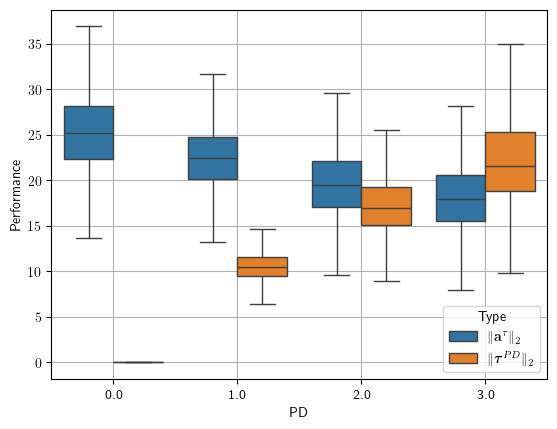

In [34]:
ax = sns.boxplot(data=per_compare_df, x="PD", y="Performance", hue="Type", showfliers=False)
ax.grid()

/tmp/ipykernel_1439065/1652589887.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(np.round(ax.get_yticks(),0), fontsize=12)
/tmp/ipykernel_1439065/1652589887.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.round(ax.get_xticks(),1), fontsize=12)


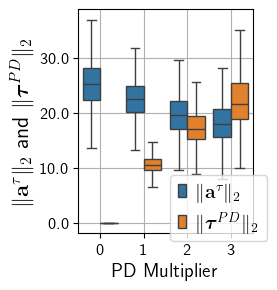

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(2.25, 2.9))

sns.boxplot(data=per_compare_df, x="PD", y="Performance", hue="Type", showfliers=False, ax=ax)
ax.grid()
ax.set_ylabel(r"$\Vert\mathbf{a}^{\tau}\Vert_{2}$ and $\Vert\boldsymbol{\tau}^{PD}\Vert_{2}$", fontsize=16)
ax.set_xlabel("PD Multiplier", fontsize=14)
ax.legend(
    loc="lower left",
    bbox_to_anchor=(0.47, -0.08),  # just outside upper-right
    ncol=1,          # or more, depending on entries
    frameon=True,
    fontsize=14,
    handlelength=0.4,    # shorter legend lines
    handletextpad=0.6)    # spacing between line and text)
# ax.set_ylabel("PD Torque Norm (Nm)")
# fig.tight_layout()
ax.set_yticklabels(np.round(ax.get_yticks(),0), fontsize=12)
ax.set_xticklabels(np.round(ax.get_xticks(),1), fontsize=12)

fig.savefig(
    "pd_mult_vs_taus.png",
    dpi=1000,
    bbox_inches="tight",
    pad_inches=0.02
)